In [130]:
import pandas as pd 
df = pd.read_csv(r"C:\Users\ibrahim khan\Desktop\MSC_Project\powerconsumption.csv")


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964
...,...,...,...,...,...,...,...,...,...
52411,12/30/2017 23:10,7.010,72.4,0.080,0.040,0.096,31160.45627,26857.31820,14780.31212
52412,12/30/2017 23:20,6.947,72.6,0.082,0.051,0.093,30430.41825,26124.57809,14428.81152
52413,12/30/2017 23:30,6.900,72.8,0.086,0.084,0.074,29590.87452,25277.69254,13806.48259
52414,12/30/2017 23:40,6.758,73.0,0.080,0.066,0.089,28958.17490,24692.23688,13512.60504


In [148]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['hour'] = df['Datetime'].dt.hour
df['Day'] = df['Datetime'].dt.day
df['Month'] = df['Datetime'].dt.month


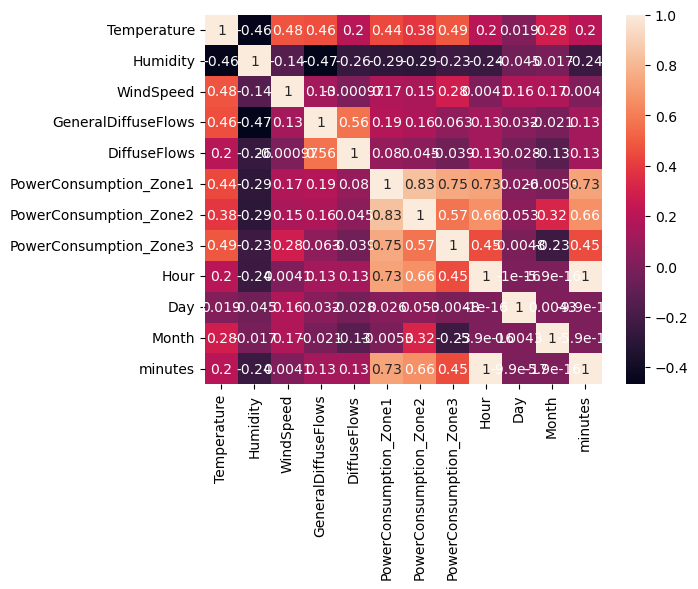

In [144]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

plt.show()

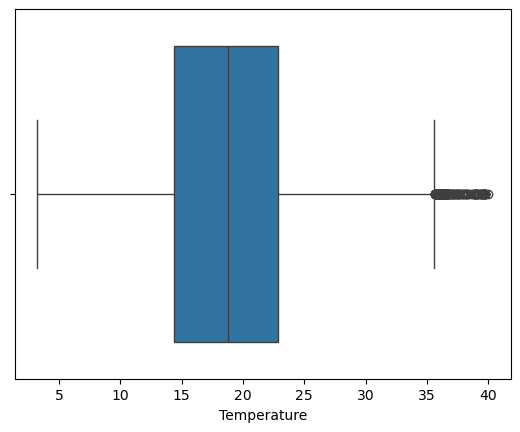

In [145]:
sns.boxplot(x=df['Temperature'])
plt.show()

In [39]:
# 4. Handle outliers
Q1 = df['Temperature'].quantile(0.25)
Q3 = df['Temperature'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Temperature'] >= Q1 - 1.5*IQR) &
        (df['Temperature'] <= Q3 + 1.5*IQR)]

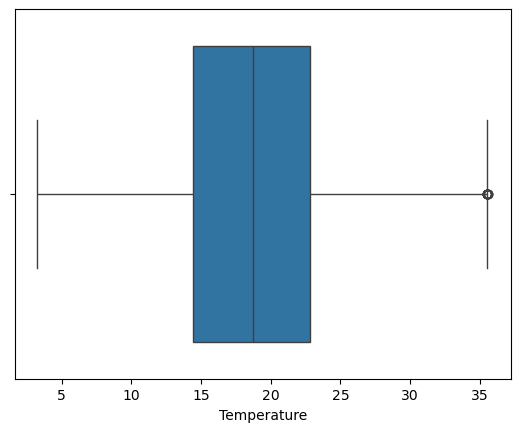

In [40]:
sns.boxplot(x=df['Temperature'])
plt.show()

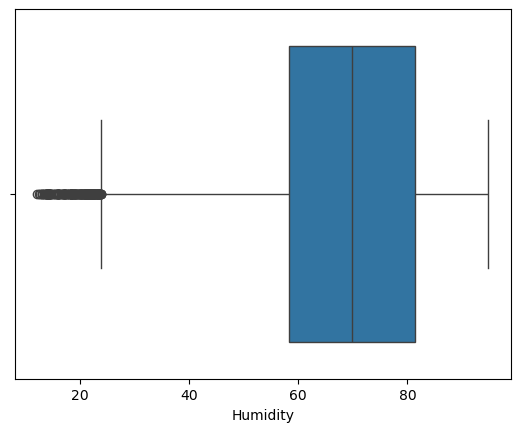

In [41]:
sns.boxplot(x=df['Humidity'])
plt.show() 

In [43]:
Q1 = df['Humidity'].quantile(0.25)
Q3 = df['Humidity'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Humidity'] >= Q1 - 1.5*IQR) &
        (df['Humidity'] <= Q3 + 1.5*IQR)]

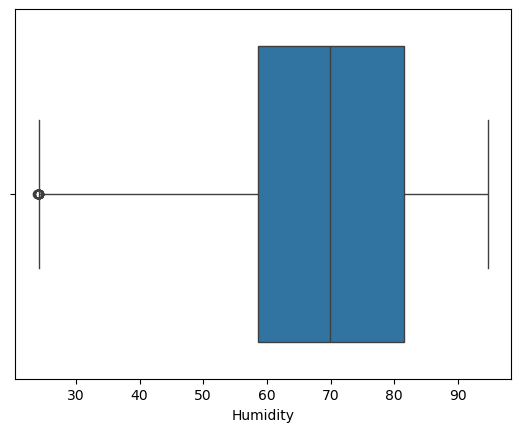

In [44]:
sns.boxplot(x=df['Humidity'])
plt.show()

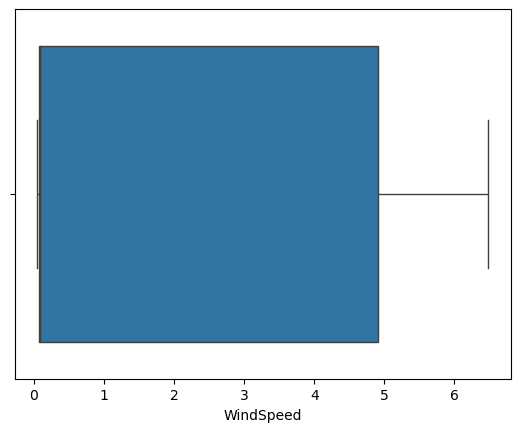

In [50]:
sns.boxplot(x=df['WindSpeed'])

plt.show()

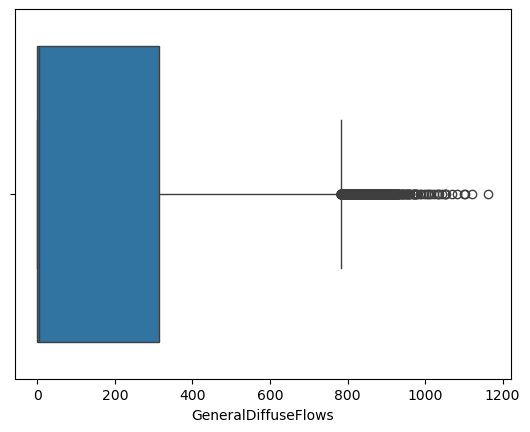

In [51]:

sns.boxplot(x=df['GeneralDiffuseFlows'])

plt.show()

In [52]:
Q1 = df['GeneralDiffuseFlows'].quantile(0.25)
Q3 = df['GeneralDiffuseFlows'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['GeneralDiffuseFlows'] < lower) |
              (df['GeneralDiffuseFlows'] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 2508


In [53]:
import numpy as np 
df['GeneralDiffuseFlows'] = np.log1p(df['GeneralDiffuseFlows'])

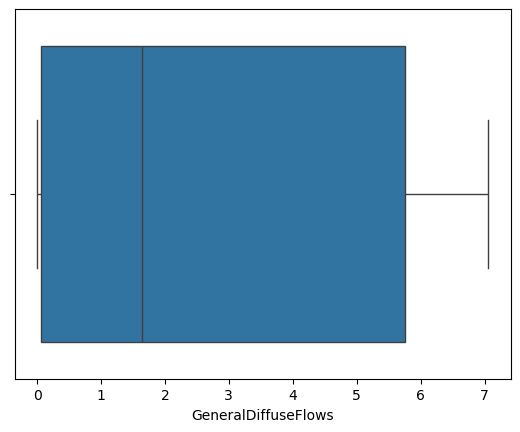

In [54]:
sns.boxplot(x=df['GeneralDiffuseFlows'])

plt.show()

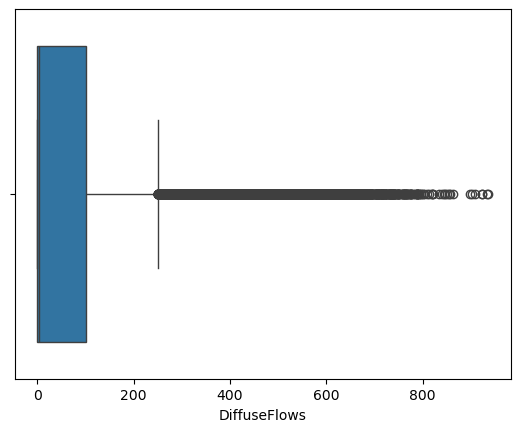

In [55]:
sns.boxplot(x=df['DiffuseFlows'])

plt.show()

In [57]:
Q1 = df['DiffuseFlows'].quantile(0.25)
Q3 = df['DiffuseFlows'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['DiffuseFlows'] < lower) |
              (df['DiffuseFlows'] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 4602


In [58]:
import numpy as np

df['DiffuseFlows'] = np.log1p(df['DiffuseFlows'])

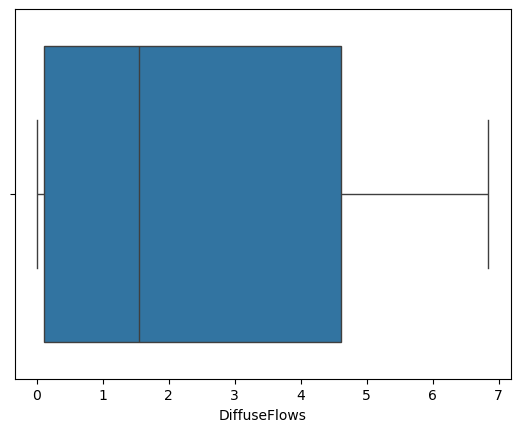

In [59]:
sns.boxplot(x=df['DiffuseFlows'])

plt.show()

In [60]:
Q1 = df['DiffuseFlows'].quantile(0.25)
Q3 = df['DiffuseFlows'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['DiffuseFlows'] < lower) |
              (df['DiffuseFlows'] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 0


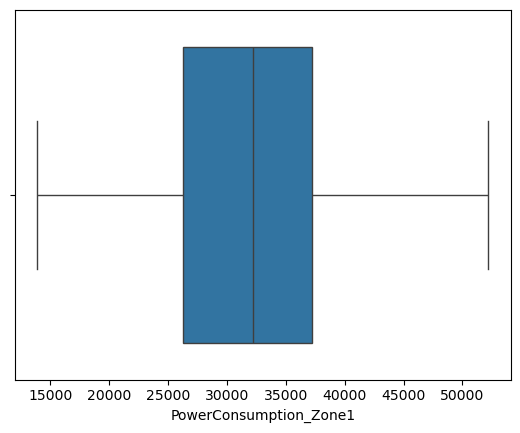

In [61]:

sns.boxplot(x=df['PowerConsumption_Zone1'])

plt.show()

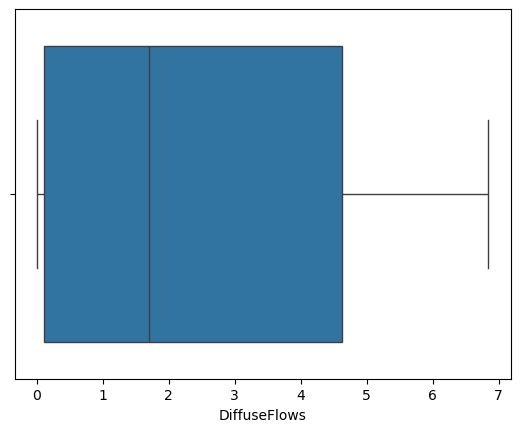

In [155]:
df['DiffuseFlows'] = np.log1p(df['DiffuseFlows'])
sns.boxplot(x=df['DiffuseFlows'])

plt.show()

In [160]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
X = df[['Temperature',
        'Humidity',
        'WindSpeed',
        'GeneralDiffuseFlows',
        'DiffuseFlows',
        'Hour',
        'Day',
        'Month']]
y = df[['PowerConsumption_Zone1', 'PowerConsumption_Zone2' , 'PowerConsumption_Zone3' ]]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Evaluate model
r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: 0.9848722586853067
